<a href="https://colab.research.google.com/github/ljzier/ST-554-repo/blob/main/ST_554_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Linda Zier**

**ST 554**

**HW #5**

#Part I - Concepts
1. The “Five V’s of Big Data”:
One place I've encountered big data is in working with a client that is trying to link Social media with ticket sales.  Specifically, the 5 V's show up in the folowing ways:

*   **Volume:** There is a very large amount of ticket sales in one database and social media posts and responses in another. There is also event data in yet another.  All of these are very large databases.
*   **Variety**: The data sources vary with some being Zoompf data from a marketing company and some being regular .csv files.


*   **Veracity**: There are lots of inconsistencies, missing values in some fields and differences in date formats making joins difficult
*   **Velocity**:  The data is always changing with time: events and social media posts are ongoing


*   **Value**: This is what we are trying to determine.  Specifically, how does social media influence ticket sales.


2. The Lahman.db that is an sqlite database that has information on Major League Baseball.


*   **Create**: This file was created by Sean Lahman and contains baseball stats going back to 1871. The people at baseball-databank.org convert it from the MS Access to MySQL so we can use it with SQLite.
*   **Read**: We will of course need to read this information so wwe can acces the baseball stats.  This is the main purpose of this database.

*   **Update**: Baseball is ongoing so the database must continually be updated
*   **Delete**: This is a changing database. Deletions are  necessary for any number of reasons as this is contantly changing data.


3. The HAVING clause when writing SQL code is used with the SELECT and GROUP BY syntax. It allows you to specify a filter condition for a group.


















#Part II - Simulation of a Sampling Distribution

Below we look at the sampling distribution of the sample slope.

We assumed the following model for SLR:
$$ Y_i = β_0 + β_1x_i + E_i $$
where the $E_i$ are assumed to be indendent and identically distributed from a standard Normal distribution
with mean 0 and variance $σ_2$ = 1.

We used the code below to generate data from this model by assuming values for β0, β1, and n, along with a sequence
of x values.


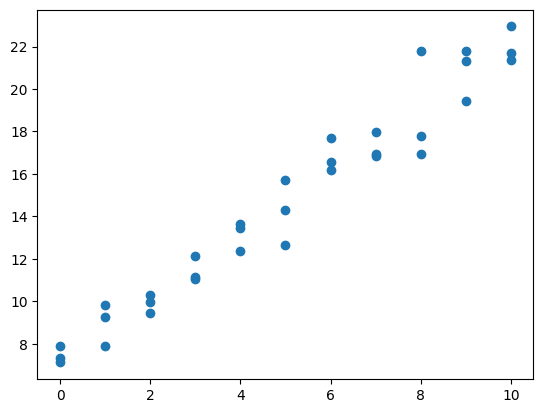

In [ ]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()


We created a regression line to estimate the slope. We then repeated the process 5000 times, saved the estimated slope values and plotted a histogram of the sample slope values.

7.359687529468447 [1.49946225]


<function matplotlib.pyplot.show(close=None, block=None)>

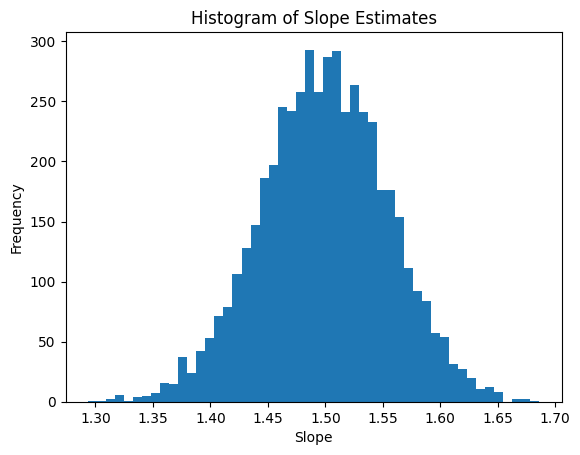

In [ ]:
from sklearn import linear_model

# create a regresion object
reg = linear_model.LinearRegression()

# fit an SLR line
reg.fit(x.reshape(-1, 1), y)
print(reg.intercept_, reg.coef_)

#initialize values
B=5000
slope_ests = np.zeros(B)  # B zeros in an array

#repeat B times
for i in range(B):
    #create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)

    # fit the line
    reg.fit(x.reshape(-1, 1), y)

    #save the slope
    slope_ests[i] = reg.coef_[0]

#visualize the data
plt.hist(slope_ests, bins = 50)
plt.title('Histogram of Slope Estimates')
plt.xlabel('Slope')
plt.ylabel('Frequency')
plt.show

To approximate the probability of observing a sample slope larger than 1.65, we can look at the proportion of values greater than 1.65.

In [ ]:
# Calculate the proportion above 1.65
p_hat = np.sum(slope_ests > 1.65) / B

print(f'The approximate probability of getting a sample slope > 1.65 is', p_hat)


The approximate probability of getting a sample slope > 1.65 is 0.0014


This represents the probability of getting a slope of 1.65 when the mean slope is 1.5.  This is the idea behind hypothesis tests.  In this case, because the probability is 0.0014, it is highly unlikely and $H_{0}$ would be rejected if that was the null hypothesis.

This value is also significant because it is the equivalent of getting a p-value of 0.05 for a standard normal.  This is the typical cut-off point for hypothesis testing; specifically for proving that $H_{0}$ is highly improbable and rejecting $H_{0}$. However, in our case, we don't have a standard normal because the mean is approximately 1.5 (by design, since we set $\beta_{1}$ = 1.5)


#Part III - Big Data Examples & Rare Events

5. In “Biases in machine learning models and big data analytics: The international criminal and humanitarian law implications” by Nema Milaninia, one of the issues around the data is that reporting and selection biases have the effect of devaluing under-reported crimes. Models based on that data set carry over the biases and hinder the prosecutor's ability to detect, investigate, and prosecute marginalized crimes. In particular, Sexual Gender-Based Crimes(SGBC) are under-reported which can lead to ML models underestimating the prevalence and patterns of these crimes. An example given in the article was a Harvard medical school study that found fewer than half of thesexual assaults on female US army soldiers appeared in official records.

    Because this under-reporting are systematically missing from databases in a predictable way tied to stigma, access, and institutional trust, statisticians have multiple ways they can address this. One way is survey based adjustment which uses victim surveys alongside official records to model the reporting gap and scale observed accounts accordingly.


6. This  article on big data usage by Vance et al. discusses how big data is reshaping three different Earth science fields, but I’m going to focus specifically on oceanography. For a long time, scientists have wanted to understand the ocean as a fully three-dimensional system. The problem has always been data, especially data from deeper parts of the ocean. Historically, those areas were just really hard to observe consistently.

    The authors explain how that is starting to change. Technologies like Argo floats, autonomous surface and underwater vehicles, and fixed ocean observatories are now collecting and transmitting real-time data, even in places that used to be data-poor. All of this information feeds into ocean models that assimilate real-time observations, making them more detailed and more accurate. They point out that the newer CMIP6 models do a better job capturing oxygen levels at depth and representing deep-ocean ventilation compared to earlier versions, which shows real progress.

    There are still concerns about bias and missing data. These technologies aren’t evenly distributed around the globe. Argo floats and observatories tend to be placed in areas that are easier to access or of greater research interest, which means remote or politically difficult regions are still underrepresented. That’s essentially a form of selection bias. The authors also note that model accuracy depends heavily on data quality, and veracity which is still a challenge. If sensors aren’t calibrated consistently or if there are transmission errors, measurement bias can creep in. Finally, because so much data collection relies on autonomous systems, rare or extreme events could be missed if they happen between sampling intervals. That creates potential temporal gaps and may underrepresent short-lived but important phenomena.

    Overall, while big data has clearly improved ocean modeling, it’s important to recognize that these systems are still shaped by where and how data is collected.

7. I love this article and the title.  The statistician is clearly making fun of himself a little.  There are so many imporant applications for understanding rare events.  I am an engineer by original degree and one thing that I'm hearing a lot about now is battery management in electric vehicles.  There are very rare cases where batteries fail in a dangerous way (from excess heat) and being able to model that behavior and understand the risks is really important.


# Part IV - Querying a database
8. Below I have connected the baseball database and looked at all the tables.


In [ ]:
# practice on querying a data base
import pandas as pd
import sqlite3
import numpy as np

#make the connection to the db
con = sqlite3.connect("lahman_1871-2022.sqlite")

get_schema = '''
    SELECT *
    FROM sqlite_schema
    WHERE type ='table'
    '''
df = pd.read_sql(get_schema, con)
print(df)



     type                 name             tbl_name  rootpage  \
0   table          AllstarFull          AllstarFull         2   
1   table          Appearances          Appearances         3   
2   table       AwardsManagers       AwardsManagers         4   
3   table        AwardsPlayers        AwardsPlayers         5   
4   table  AwardsShareManagers  AwardsShareManagers         6   
5   table   AwardsSharePlayers   AwardsSharePlayers         7   
6   table              Batting              Batting         8   
7   table          BattingPost          BattingPost         9   
8   table       CollegePlaying       CollegePlaying        10   
9   table             Fielding             Fielding        11   
10  table           FieldingOF           FieldingOF        12   
11  table      FieldingOFsplit      FieldingOFsplit        13   
12  table         FieldingPost         FieldingPost        14   
13  table           HallOfFame           HallOfFame        15   
14  table            Home


9. Here is an SQL query using pd.read_sql() that returns all the teams that played in the year 2015 with
all of the corresponding columns from the Teams table.


In [ ]:
#see what the year is in the Teams table
df=pd.read_sql('SELECT * FROM Teams LIMIT 5', con)
#print(df.columns)

# now select only 2015
df=pd.read_sql('SELECT * FROM Teams WHERE yearID = 2015', con)
print(df)

    yearID lgID teamID franchID divID  Rank    G  Ghome    W   L  ...   DP  \
0     2015   AL    BAL      BAL     E     3  162     78   81  81  ...  134   
1     2015   AL    BOS      BOS     E     5  162     81   78  84  ...  148   
2     2015   AL    CHA      CHW     C     4  162     81   76  86  ...  159   
3     2015   AL    CLE      CLE     C     3  161     80   81  80  ...  136   
4     2015   AL    DET      DET     C     5  161     81   74  87  ...  165   
5     2015   AL    HOU      HOU     W     2  162     81   86  76  ...  131   
6     2015   AL    KCA      KCR     C     1  162     81   95  67  ...  138   
7     2015   AL    LAA      ANA     W     3  162     81   85  77  ...  108   
8     2015   AL    MIN      MIN     C     2  162     81   83  79  ...  150   
9     2015   AL    NYA      NYY     E     2  162     81   87  75  ...  135   
10    2015   AL    OAK      OAK     W     5  162     81   68  94  ...  154   
11    2015   AL    SEA      SEA     W     4  162     81   76  86

10. Below is an SQL query using pd.read_sql() that returns all of the players in the hall of fame, the year
they were voted into the hall of fame, and their category.



In [93]:
#see what the columns are in the hall of fame table
df=pd.read_sql("SELECT * FROM HallOfFame LIMIT 5", con)
print(df.columns)

# now select players in the Hall of Fame, their induction year, and category
# where category = Player
get_HOF = '''
    SELECT playerID, yearid, category
    FROM HallOfFame
    WHERE (inducted = 'Y')     '''
df = pd.read_sql(get_HOF, con)
print(df)


Index(['playerID', 'yearid', 'votedBy', 'ballots', 'needed', 'votes',
       'inducted', 'category', 'needed_note'],
      dtype='object')
      playerID  yearid           category
0    aaronha01    1982             Player
1    alexape01    1938             Player
2    alomaro01    2011             Player
3    alstowa01    1983            Manager
4    andersp01    2000            Manager
..         ...     ...                ...
335  yastrca01    1989             Player
336  yawketo99    1980  Pioneer/Executive
337  youngcy01    1937             Player
338  youngro01    1972             Player
339  yountro01    1999             Player

[340 rows x 3 columns]


11. The query below is an SQL query using pd.read_sql() that return all unique managers of the Pittsburgh Pirates (teamID of PIT) and only that information from the Managers table.


In [94]:

#see what the columns are in the Managers table
#df=pd.read_sql("SELECT * FROM Managers LIMIT 25", con)
#df

# now select all unique managers of the Pittsburgh Pirates
get_Pit_mgr = '''
    SELECT DISTINCT playerID
    FROM Managers
    WHERE teamID = 'PIT'
    '''
df = pd.read_sql(get_Pit_mgr, con)
print(df)

     playerID
0   bezdehu99
1   bragabo01
2   buckeal99
3   burnsto01
4   burwebi01
5    bushdo01
6   callani01
7   clarkfr01
8   davissp01
9   donovpa01
10  dunlafr01
11    ensje01
12  friscfr01
13  gibsoge01
14  grammal01
15  haneyfr01
16  hanlone01
17  heckegu01
18  hermabi01
19  hurdlcl01
20  lamonge01
21  leylaji99
22  mackape01
23   mackco01
24  mcclell01
25  mcgunbi01
26  mckecbi01
27  meyerbi01
28  murtada01
29  phillho99
30  princto01
31  russejo02
32  sheltde99
33  shepala99
34  tannech01
35  tracyji01
36  traynpi01
37  virdobi01
38  wagneho01
39  walkeha01
40  watkibi01


12. This SQL code uses the HallOfFame and Managers tables to return all of the playerIDs for the people
that managed for a team that were inducted into the hall of fame. It also reports the overall number of such people.

In [95]:

# inner join that with those that also managed a team

inner = '''
    SELECT DISTINCT HOF.playerID, HOF.category FROM HallOfFame as HOF
    INNER JOIN Managers as M ON HOF.playerID = M.playerID
    WHERE (HOF.inducted = 'Y')
    '''
df=pd.read_sql(inner, con)
print(df)

#PRINT THE NUMBER BY COUNTING ROWS
print(f'the number of people that were players and managers ')
print(f'and made it into the HOF are:', len(df))



     playerID           category
0   alstowa01            Manager
1   andersp01            Manager
2   ansonca01             Player
3   applilu01             Player
4   baineha01             Player
..        ...                ...
92  willidi02            Manager
93  willite01             Player
94  wrighge01  Pioneer/Executive
95  wrighha01  Pioneer/Executive
96  youngcy01             Player

[97 rows x 2 columns]
the number of people that were players and managers 
and made it into the HOF are: 97


13. This SQL query returns every season
managed by each manager that made it to the hall of fame including their games, wins, and losses.
Next,it determines the overall win/loss records (sum of wins and sum of losses) for each of these hall of fame managers. Then it creates a new variable that is the win/loss percentage (W/(W+L)). Lastly, it sorts in descending order by the win/loss percentage variable.

In [96]:
# Wins and Losses for HOF managers
record = '''
    SELECT M.playerID, M.G, M.W, M.L FROM MANAGERS as M
    INNER JOIN HallOfFame as HOF ON M.playerID = HOF.playerID
    WHERE (HOF.inducted = 'Y')
    '''
df = pd.read_sql(record, con)

# Calculate overall wins, losses, and win/loss percentage for each manager
#I saved in a new database
df2 = df.groupby('playerID').agg(wins=('W', 'sum'), losses=('L', 'sum')).reset_index()
df2['percentage'] = df2['wins'] / (df2['wins'] + df2['losses'])
df2 = df2.sort_values(by='percentage', ascending=False)

print(df2)

     playerID  wins  losses  percentage
75  simmote01     1       0    1.000000
94  wrighge01    59      25    0.702381
78  spaldal01    78      47    0.624000
57  mccarjo99  2125    1333    0.614517
19  comisch01   840     541    0.608255
..        ...   ...     ...         ...
8   bottoji01    21      56    0.272727
3   applilu01    10      30    0.250000
4   baineha01     1       3    0.250000
86  wagneho01     1       4    0.200000
20  connoro01     8      37    0.177778

[97 rows x 4 columns]
